# Проект спринта 11: Модель для прогнозирования оттока клиентов для сервиса доставки кофе

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 30 мая 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/project_happy_coffe_beans

## Описание задачи
Компания **Happy Beans Coffee** ранее она занималась производством кофемашин и продажей элитного кофе, а недавно запустила собственный сервис по его доставке, и ей нужен совет по поводу удержания покупателей.
На рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц сервис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы.  

Необходимо построить **модель бинарной классификации на основе Логистической регрессии** `LogisticRegression`, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце.  
В качестве основной метрики оценки качества модели будет использованы **Precision-Recall AUC (PR AUC)**. Она фокусируется на корректном предсказании меньшего по объёму, но ключевого для задачи класса — уходящих клиентов.

## Описание данных

Для решения задачи аналитики компании Happy Beans Coffee подготовили датасет `coffee_churn_dataset`, доступный для загрузки по ссылке https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv. Данные были собраны из внутренних систем компании: транзакционной базы данных, логов мобильного приложения и результатов опросов.  

Что важно знать про данные:  
- Период агрегации. Признаки агрегированы за последние 4 недели.  
- Формат данных. Они представлены в виде готовой аналитической витрины. Это означает, что для каждого клиента уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.  
- Структура. Каждая строка — это один уникальный клиент. Все признаки уже вычислены и представлены в виде числовых и категориальных значений.  



## Признаки в датасете
- `user_id` — идентификатор пользователя.

- `days_since_last_order` — количество дней, прошедших с последнего заказа.
- `order_frequency_month` — среднее число заказов в месяц.
- `order_frequency_week` — среднее число заказов в неделю.
- `avg_order_value` — средний чек, в рублях.
- `median_order_value` — медианный чек, в рублях.
- `total_spent_last_month` — сумма заказов за последний месяц.
- `total_spent_last_week` — сумма заказов за последнюю неделю.
- `discount_usage_rate` — доля заказов со скидкой за последний месяц.
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
- `preferred_roast` — предпочитаемый тип обжарки.
- `milk_preference` — предпочитаемый тип молока.
- `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.
- `coffee_bean_origin` — страна происхождения зерна.
- `last_drink_size` — размер последнего заказа, совершённого на момент сбора данных.
- `subscription_status` — тип подписки пользователя.
- `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
- `notifications_enabled` — включены ли у пользователя уведомления.
- `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.
- `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.
- `seasons` — текущее время года.
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.
- `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.
- `geo_id` — идентификатор региона пользователя.
- `churn` — перестал ли пользователь пользоваться сервисом.

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установка и настройка библиотек.

2. Фиксация `random_state`.

3. Загрузка данных из CSV-файла.

In [1]:
# Загружаем библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

random_state = 52


In [2]:
df_init = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

In [3]:
df_init.head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,medium,whole,0.0,kenya,large,none,5.064097,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,dark,soy,1.0,NaN,medium,none,11.658836,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,light,almond,1.0,brazil,small,basic,14.785010,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,medium,skim,1.0,guatemala,medium,NaN,7.129673,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,light,whole,NaN,guatemala,medium,NaN,6.706418,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


In [4]:
df_init.tail(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
10440,user_08322,1.0,NaN,NaN,2695.255441,844.506512,950.584559,246.319457,0.195791,arabica,dark,NaN,1.0,guatemala,large,basic,7.554070,1.0,4.901340,5.432583,0.0,winter,1.0,android,0.0,geo_3,0
10441,user_05578,12.0,2.900701,1.012398,1285.212358,952.963536,2689.715770,897.864812,0.312848,robusta,medium,none,1.0,colombia,small,none,9.395250,1.0,4.587667,5.064741,2.0,spring,42.0,ios,0.0,geo_2,0
10442,user_04426,1.0,3.713244,0.746802,1383.203467,778.555253,3098.539559,725.161728,0.487344,robusta,medium,soy,1.0,brazil,NaN,none,9.100238,0.0,3.867784,2.274575,3.0,summer,21.0,ios,0.0,geo_95,1
10443,user_00466,NaN,0.783890,0.082255,1587.816015,582.698318,489.770711,37.171851,0.123220,blend,medium,almond,1.0,ethiopia,small,NaN,5.090770,NaN,4.952929,6.247028,1.0,winter,3.0,android,0.0,geo_22,0
10444,user_06265,3.0,11.610820,2.656258,1009.178893,386.098118,5154.343248,748.198406,0.341967,arabica,light,whole,1.0,vietnam,medium,none,13.902952,1.0,NaN,NaN,1.0,spring,11.0,android,1.0,geo_24,0
10445,user_05734,5.0,NaN,0.807372,288.187339,NaN,465.497296,82.772110,0.285469,arabica,medium,none,1.0,brazil,small,none,8.338420,1.0,3.149287,5.180760,NaN,summer,2.0,android,NaN,NaN,0
10446,user_05191,NaN,8.265273,1.942752,1151.879696,392.095861,3323.512340,535.414300,0.172886,blend,dark,none,1.0,brazil,medium,basic,5.636823,1.0,5.144074,2.438754,NaN,winter,17.0,ios,1.0,geo_36,0
10447,user_05390,0.0,4.303173,1.029802,1303.253909,477.969319,1854.476109,551.436986,0.502961,arabica,light,skim,1.0,NaN,large,none,NaN,1.0,3.975122,5.018790,1.0,winter,7.0,ios,0.0,geo_12,0
10448,user_00860,7.0,1.964595,0.350771,965.339923,465.489241,833.596910,203.599663,0.137200,arabica,dark,whole,1.0,NaN,medium,basic,8.128741,0.0,4.564480,2.024267,1.0,autumn,NaN,ios,0.0,geo_3,0
10449,user_07270,1.0,9.731682,2.257865,1019.691126,454.191202,4343.690591,851.127412,NaN,robusta,dark,whole,1.0,brazil,medium,none,11.643731,1.0,4.827017,4.485083,0.0,summer,18.0,ios,0.0,geo_1,0


In [5]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [6]:
dataset_cols_float = df_init.select_dtypes(include=['float64']).columns.tolist()

for col in dataset_cols_float:
    df_init[col] = pd.to_numeric(df_init[col], downcast='float')

df_init['churn'] = pd.to_numeric(df_init['churn'], downcast='integer')

In [7]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

## Комментарий

1) Импортированы нужные **библиотеки**, создан файл **requirements.txt** и размещён в репозитории GitHub, зафиксирован **random_state**.  
2) Данные успешно загружены из указанной ссылки https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv  
3) В датасете всего 27 признаков. Из них 16 числовых типа `float`, 10 признаков типа `str`, куда входят идентификаторы и категориальные переменные. Целевая переменная `churn` имеет целочисленный тип.   
4) Численные типы данных оптимизированы: `float64` приведены к `float32`, целевая переменная `churn` приведена от типа данных `int64` к `int8`. 
___

## Этап 2. Первичный анализ данных

1. Описание данных. Что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.
---
7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.
___

### 1. Описание данных. Что известно о пользователях и их поведении.

In [8]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [9]:
df_init['user_id'].nunique()

10450

In [10]:
num_features = df_init.select_dtypes(include=['float64', 'float32']).columns.tolist()
cat_features = df_init.select_dtypes(include=['str']).columns.tolist()

In [11]:
df_init[num_features].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000
mean,4.394214,4.025666,0.930686,1063.741211,452.651520,1946.132979,413.004730,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480
std,4.858757,2.826144,0.657261,707.713379,258.657562,2370.619590,445.634918,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308868,0.394268
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559570,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898682,262.908600,629.680382,136.565826,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643555,406.456818,1300.409757,288.277344,0.264583,1.000000,9.228382,1.000000,4.203555,3.990031,1.000000,10.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418091,2481.650495,549.699402,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965332,2189.101562,79298.849570,8615.989258,0.887301,1.000000,224.587875,1.000000,7.384425,8.558442,7.000000,140.000000,1.000000


In [12]:
df_init[cat_features].describe()

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_00318,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


### Комментарий

В датасете представлена подробная статистика по **10 450** пользователям сервиса доставки кофе. Судя по числовым метрикам, пользователи демонстрируют умеренную лояльность: среднее количество дней с последнего заказа составляет около 4,3, а средняя частота заказов — чуть более 4 в месяц. Средний чек (`avg_order_value`) находится на уровне ~1063 рублей, при этом разброс значений велик (от отрицательных значений до 5901 рубля), что говорит о наличии как экономных, так и премиальных клиентов. Пользователи активно взаимодействуют с приложением: в среднем открывают его 11 раз в неделю, а около 75% регулярно пробуют новинки (показатель `seasonal_menu_tried` близок к 1).

Что касается категорийных признаков, выявлены устойчивые предпочтения аудитории. Наиболее популярным сортом кофе является **арабика** (выбран более чем 60% пользователей), а самой востребованной обжаркой — **средняя**. Большинство клиентов заказывают напитки с **цельным молоком**, а размер порции чаще всего выбирают **средний**. География и устройства показывают разнообразие: пользователи распределены минимум по 100 регионам (`geo_location`), а около 46% совершают покупки с устройств на **Android**. При этом уровень вовлеченности неоднороден: значительная часть пользователей не имеет активной подписки (`subscription_status` = `none`), а оценки последних заказов варьируются, что требует внимания к качеству сервиса.
___

### 2. Описание целевой переменной. Особенности её распределения. Дисбаланс классов в целевой переменной.

In [13]:
df_init['churn'].describe()

count    10450.000000
mean         0.060191
std          0.237852
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churn, dtype: float64

In [14]:
df_init['churn'].value_counts(normalize=True)

churn
0    0.939809
1    0.060191
Name: proportion, dtype: float64

In [15]:
# Функция построние столбчатой диаграммы с метками данных

def plot_bar_chart(data, xlabel='Категория', ylabel='Количество', title='Столбчатая диаграмма'):
    """
    Строит столбчатую диаграмму с метками значений и процентов.

    Параметры:
    -----------
    data : array-like или pd.Series
        Вектор данных для построения диаграммы.
    xlabel : str, optional
        Подпись оси X (по умолчанию 'Категория').
    ylabel : str, optional
        Подпись оси Y (по умолчанию 'Количество').
    title : str, optional
        Заголовок графика (по умолчанию 'Столбчатая диаграмма').
    """
    # Преобразуем данные в Series, если это ещё не сделано
    if not isinstance(data, pd.Series):
        data = pd.Series(data)
    
    # Подсчёт значений
    value_counts = data.value_counts()
    value_counts_normalized = data.value_counts(normalize=True)
    total = value_counts.sum()

    # Создаём контейнер графика matplotlib и задаём его размер
    plt.figure(figsize=(12, 6))

    # Строим столбчатую диаграмму
    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    # Добавляем сетку графика
    plt.grid(axis='y', linestyle='--')

    # Добавление меток на столбики (абсолютные значения)
    for i, v in enumerate(value_counts):
        ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)

    # Добавление меток процентов
    for i, v in enumerate(value_counts_normalized):
        # Позиция по Y — половина высоты столбца (чтобы надпись была по центру)
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white'
        )

    # Выводим график
    plt.show()


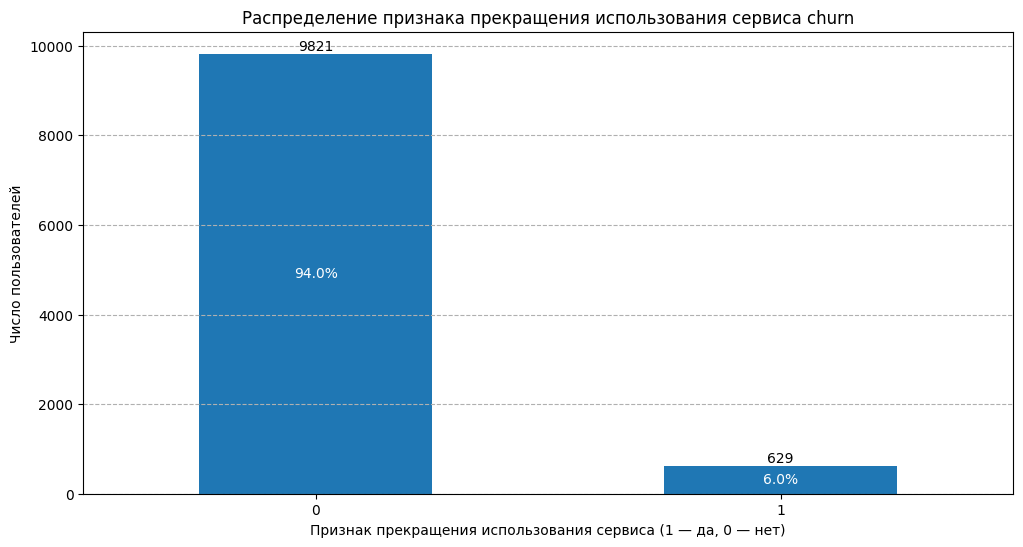

In [16]:
plot_bar_chart(
    df_init['churn'],
    xlabel='Признак прекращения использования сервиса (1 — да, 0 — нет)',
    ylabel='Число пользователей',
    title='Распределение признака прекращения использования сервиса churn'
)


### Комментарий

Целевая переменная `churn` представляет собой флаг признака оттока клиентов: значение 1 - клиент прекратил пользоваться сервисом, 0 - клиент остался в сервисе.  
Явно заметен дисбаланс значений переменной. **6%** пользователей прекратили пользоватьс ясервисом за последние 4 недели. **94%** не имеют такого признака.
___


### 3. Описание признаков. Определим, все ли из них важны. Какие из них можно удалить (если такие есть).

In [17]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [18]:
df_processed = df_init.drop(columns=['user_id', 'seasons'])
df_processed.head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833862,260.645081,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1
1,2.0,1.569146,0.214494,780.135132,540.597839,998.380941,107.369408,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,16.0,ios,0.0,geo_95,0
2,11.0,2.996666,0.771864,682.636230,471.494568,1328.140204,392.600006,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895638,1.0,4.977713,4.379219,0.0,11.0,web,1.0,geo_25,0
3,0.0,4.299255,1.210480,2115.487305,708.529785,2999.628366,1084.352051,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043617,0.0,3.0,android,0.0,geo_2,0
4,3.0,7.249865,1.761027,3519.602051,1199.372925,8377.729478,2551.775146,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948238,0.0,4.528271,5.642993,1.0,14.0,ios,0.0,geo_19,1


In [19]:
# обновим после удаления части признаков группы cat_features и создадим binary_features
cat_features = df_processed.select_dtypes(include=['str']).columns.tolist()
binary_features = ['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change']

### Комментарий

В датасете есть 26 признаков и целевая переменная `churn`.

Информация о пользователях (14 признаков): идентификатор пользователя, предпочитаемый тип обжарки, предпочитаемый тип молока, отметка пробовал ли пользователь сезонное меню, тип подписки пользователя, тип устройства пользователя, сколько раз за неделю пользователь открывал приложение, включены ли уведомления, сколько раз приложение зависало, информация об оценках пользователя, как давно использовалась акция или промокод, менялись ли предпочтения пользователя, регион пользователя.

Информация о заказах пользователей и характеристики этих заказов.  
Числовые характеристики заказов (8 признаков) : число и суммы заказов за неделю и за месяц, средняя и медианная сумма чека, количество дней с последнего заказа, доля заказов со скидкой, размер последнего заказа.  
Категориальные характеристики заказов (3 признака): последний купленный сорт кофе, последний купленный размер кофе, страна происхождения зерна.

Прочая информация: текущее время года (1 признак).

Важными для последующего анализа и построения модели являются числовые и категориальные характеристики заказов, также важны характеристики пользователей, что они предпочитают, какими устройствами пользуются, как стабильно работает приложение и другие.

Почти все атрибуты потенциально могут оказывать влияние на целевую переменную и их необходимо включить в дальнейший анализ.

К признакам, которые не несут в себе полезной информации можно отнести идентификатор пользователя `user_id`. Не ясен статус атрибута текущий сезон `seasons`: данные агрегированы за последние 4 недели, что имелось ввиду под "текущим сезоном" понять затруднительно. Удаляем.

Итого у нас остается 24 признака.
___




### 4. Обработка пропущенные значения. Влияние пропусков на данные. Стратегия заполнения пропусков.

In [20]:
def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

show_missing_stats(df_processed)

,Кол-во пропусков,Доля пропусков
seasonal_menu_tried,989,0.0946
days_since_last_order,945,0.0904
total_spent_last_week,944,0.0903
subscription_status,938,0.0898
app_opens_per_week,896,0.0857
review_rating_last_1,857,0.0820
median_order_value,831,0.0795
days_since_last_promo,731,0.0700
app_crashes_last_month,721,0.0690
review_rating_last_10,693,0.0663


In [21]:
# Количество атрибутов с пропусками
np.sum(df_processed.isna().sum() > 0)

np.int64(24)

In [22]:
df_processed.sample(20)

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
4214,0.0,1.399606,NaN,2254.957031,720.203552,987.954084,206.003250,0.575630,blend,light,skim,0.0,kenya,medium,none,6.954070,1.0,4.611352,4.194499,0.0,5.0,android,1.0,geo_1,0
6322,3.0,2.236990,0.338510,1650.406128,637.577271,1579.283816,215.005707,NaN,robusta,light,soy,1.0,vietnam,large,none,10.767490,1.0,4.756640,4.516642,0.0,1.0,ios,0.0,geo_84,0
9962,12.0,8.971120,2.026666,NaN,354.469238,NaN,748.226379,0.165599,robusta,light,whole,1.0,vietnam,large,premium,15.566813,0.0,2.940623,2.168859,NaN,52.0,ios,1.0,geo_3,0
9298,3.0,3.403088,0.830326,932.872986,514.677795,2069.912519,463.521240,0.198015,arabica,dark,whole,1.0,NaN,large,premium,10.788754,1.0,4.376543,NaN,1.0,9.0,android,0.0,geo_3,0
7148,4.0,3.693041,0.897454,5901.965332,1752.699097,5715.648086,1917.509399,0.369765,arabica,dark,oat,0.0,guatemala,small,basic,9.150108,0.0,5.708250,4.017034,0.0,35.0,ios,0.0,geo_13,0
4748,4.0,4.012872,0.972214,1126.280762,331.513641,1300.415016,344.379517,0.186341,arabica,NaN,oat,1.0,vietnam,small,none,5.398022,0.0,NaN,2.734466,3.0,5.0,ios,0.0,geo_100,0
6440,14.0,4.370631,NaN,956.098877,434.717438,2041.701973,459.106079,0.231191,arabica,medium,skim,1.0,colombia,large,basic,14.550833,1.0,1.709469,3.610298,0.0,8.0,ios,0.0,geo_18,0
611,NaN,5.351205,1.333699,526.288147,156.213364,959.813241,NaN,0.275821,arabica,dark,none,1.0,colombia,medium,premium,13.565575,1.0,4.222986,5.747503,0.0,41.0,ios,0.0,geo_35,0
7874,NaN,6.960521,1.687546,266.892059,198.751770,1148.188268,313.695679,0.177837,arabica,medium,soy,1.0,ethiopia,medium,none,8.749383,1.0,NaN,2.424974,1.0,13.0,android,0.0,geo_3,0
10303,3.0,NaN,0.770742,919.305237,445.181213,1719.712763,308.518402,0.110106,robusta,light,none,0.0,colombia,large,none,3.671510,1.0,4.977990,4.051962,1.0,81.0,android,0.0,geo_1,0


In [23]:
# Проверяем уникальные значения в столбцах
for column in cat_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_processed[column].sort_values().unique())
    print('Число уникальных значений:', df_processed[column].sort_values().nunique())
    print()

Уникальные значения в столбце last_coffee_type:
<StringArray>
['arabica', 'blend', 'robusta', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце preferred_roast:
<StringArray>
['dark', 'light', 'medium', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце milk_preference:
<StringArray>
['almond', 'none', 'oat', 'skim', 'soy', 'whole', nan]
Length: 7, dtype: str
Число уникальных значений: 6

Уникальные значения в столбце coffee_bean_origin:
<StringArray>
['brazil', 'colombia', 'ethiopia', 'guatemala', 'kenya', 'vietnam', nan]
Length: 7, dtype: str
Число уникальных значений: 6

Уникальные значения в столбце last_drink_size:
<StringArray>
['large', 'medium', 'small', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце subscription_status:
<StringArray>
['basic', 'none', 'premium', 'pro', nan]
Length: 5, dtype: str
Число уникальных значений: 4

Уникальные значения в столбце phone_type:

In [24]:
df_processed['subscription_status'] = df_processed['subscription_status'].fillna('none')
df_processed['milk_preference'] = df_processed['milk_preference'].fillna('none')

In [25]:
show_missing_stats(df_processed)

,Кол-во пропусков,Доля пропусков
seasonal_menu_tried,989,0.0946
days_since_last_order,945,0.0904
total_spent_last_week,944,0.0903
app_opens_per_week,896,0.0857
review_rating_last_1,857,0.0820
median_order_value,831,0.0795
days_since_last_promo,731,0.0700
app_crashes_last_month,721,0.0690
review_rating_last_10,693,0.0663
coffee_bean_origin,682,0.0653


In [26]:
# Количество атрибутов с пропусками
np.sum(df_processed.isna().sum() > 0)

np.int64(22)

In [27]:
df_processed[df_processed['order_frequency_week'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833862,260.645081,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1
8,9.0,3.303446,NaN,1886.543945,964.629211,3312.557597,748.655212,0.676576,blend,medium,skim,1.0,guatemala,medium,none,7.129673,1.0,4.405572,NaN,0.0,5.0,android,0.0,geo_45,0
21,5.0,4.289868,NaN,2678.323486,1459.123901,6913.253220,NaN,0.168081,robusta,light,none,1.0,guatemala,large,premium,9.999694,1.0,2.502726,3.759893,1.0,46.0,ios,NaN,geo_94,0
54,11.0,2.724589,NaN,1870.721191,756.890747,1931.968478,444.822388,0.515463,arabica,dark,whole,0.0,vietnam,small,none,NaN,1.0,4.049906,4.635729,1.0,12.0,ios,0.0,geo_97,0
196,0.0,2.991425,NaN,877.869812,349.251160,1024.328734,254.916000,0.498768,arabica,medium,oat,1.0,ethiopia,large,basic,8.602476,0.0,4.187550,3.713239,0.0,4.0,ios,0.0,geo_1,0


In [28]:
df_processed[df_processed['order_frequency_month'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
19,4.0,NaN,1.013600,258.936157,195.351089,610.308141,207.883087,0.443392,robusta,dark,oat,1.0,colombia,medium,basic,9.730930,1.0,3.692612,3.784187,0.0,33.0,ios,0.0,geo_17,0
36,7.0,NaN,0.694691,1012.886169,486.800598,1418.373591,407.854736,0.186249,arabica,dark,none,1.0,ethiopia,medium,none,2.773921,1.0,3.566735,3.549654,0.0,21.0,android,0.0,geo_1,0
46,7.0,NaN,0.549208,1583.349731,465.959991,1312.432324,179.851929,0.260499,robusta,dark,whole,0.0,vietnam,medium,none,9.491598,1.0,4.857894,4.647859,2.0,23.0,web,1.0,geo_43,0
74,0.0,NaN,2.502107,304.132996,160.229935,1309.437920,387.911102,0.520304,blend,light,none,1.0,vietnam,medium,premium,15.321233,1.0,NaN,3.324303,0.0,5.0,ios,0.0,geo_2,0
79,7.0,NaN,1.205580,46.113434,18.374914,120.562163,18.190657,0.666557,arabica,dark,whole,0.0,brazil,large,premium,3.173590,0.0,4.656898,3.508681,1.0,2.0,ios,0.0,geo_2,0


In [29]:
df_processed[df_processed['total_spent_last_week'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833862,260.645081,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1
17,3.0,3.503378,0.936460,1001.051575,405.030457,1584.914584,NaN,0.435147,arabica,dark,oat,0.0,NaN,medium,premium,17.655357,1.0,5.683203,5.187074,0.0,NaN,ios,0.0,geo_3,0
21,5.0,4.289868,NaN,2678.323486,1459.123901,6913.253220,NaN,0.168081,robusta,light,none,1.0,guatemala,large,premium,9.999694,1.0,2.502726,3.759893,1.0,46.0,ios,NaN,geo_94,0
43,2.0,1.379313,0.289451,1235.152954,NaN,947.938062,NaN,0.438557,robusta,medium,whole,0.0,guatemala,NaN,basic,7.711953,1.0,3.006368,NaN,1.0,33.0,android,0.0,geo_100,0
57,2.0,5.445011,1.373850,765.754333,299.811218,1885.775446,NaN,0.465748,robusta,dark,whole,0.0,ethiopia,medium,premium,17.341873,1.0,4.964828,3.794571,0.0,32.0,ios,0.0,NaN,0


In [30]:
df_processed[df_processed['total_spent_last_month'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
7,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523664,0.173646,robusta,light,almond,1.0,brazil,small,basic,14.785010,1.0,4.793547,4.321319,3.0,12.0,android,0.0,geo_3,1
18,0.0,5.236275,1.132846,2288.324707,801.929688,NaN,1000.598877,0.296605,arabica,light,skim,1.0,colombia,medium,none,6.201520,0.0,4.415193,3.125482,0.0,15.0,android,0.0,geo_2,0
39,11.0,2.997699,0.635281,1729.047852,884.359314,NaN,609.195129,0.180354,arabica,medium,none,1.0,kenya,medium,premium,7.941270,0.0,3.569873,2.650999,2.0,6.0,ios,1.0,NaN,0
77,6.0,2.318445,0.392752,1595.760376,671.527344,NaN,224.996048,0.115047,arabica,dark,oat,1.0,brazil,small,none,3.136085,1.0,4.390393,3.071448,0.0,3.0,ios,0.0,geo_1,0
80,4.0,7.813909,1.896021,748.838928,306.484528,NaN,581.097290,0.068763,arabica,light,oat,0.0,kenya,small,none,11.899315,0.0,NaN,5.466691,0.0,22.0,android,0.0,geo_3,0


In [31]:
def fill_missing_values(row):
    """
    Заполняет пропуски в парах полей week-month:
    - Если есть значение month, а week пуст — заполняет week = month / 4
    - Если есть значение week, а month пуст — заполняет month = week * 4
    - Если оба поля пусты — оставляет как есть

    Параметры:
    -----------
    row : pd.Series
        Строка датафрейма

    Возвращает:
    -----------
    pd.Series
        Обновлённая строка с заполненными пропусками (если возможно)
    """
    # Создаём копию строки, чтобы не изменять оригинальный датафрейм
    new_row = row.copy()

    # Пара: order_frequency_month и order_frequency_week
    freq_month = row['order_frequency_month']
    freq_week = row['order_frequency_week']

    if pd.isna(freq_week) and not pd.isna(freq_month):
        # Если week пуст, а month есть — заполняем week = month / 4
        new_row['order_frequency_week'] = freq_month / 4

    elif pd.isna(freq_month) and not pd.isna(freq_week):
        # Если month пуст, а week есть — заполняем month = week * 4
        new_row['order_frequency_month'] = freq_week * 4

    # Пара: total_spent_last_month и total_spent_last_week
    spent_month = row['total_spent_last_month']
    spent_week = row['total_spent_last_week']

    if pd.isna(spent_week) and not pd.isna(spent_month):
        # Если week пуст, а month есть — заполняем week = month / 4
        new_row['total_spent_last_week'] = spent_month / 4

    elif pd.isna(spent_month) and not pd.isna(spent_week):
        # Если month пуст, а week есть — заполняем month = week * 4
        new_row['total_spent_last_month'] = spent_week * 4

    return new_row


In [32]:
show_missing_stats(df_processed[['order_frequency_week', 'order_frequency_month', 'total_spent_last_week', 'total_spent_last_month']])

,Кол-во пропусков,Доля пропусков
total_spent_last_week,944,0.0903
order_frequency_month,600,0.0574
order_frequency_week,388,0.0371
total_spent_last_month,294,0.0281


In [33]:
# Применение функции к датафрейму
df_processed = df_processed.apply(fill_missing_values, axis=1)

In [34]:
# Проверим заполнение в строке с индексом 0, где были пустые значения для order_frequency_week и total_spent_last_week
df_processed.iloc[:1]

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,3.23563,316.833862,260.645081,3089.991009,772.497752,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1


In [35]:
# Проверим заполнение в строке с индексами 18 и 19, где были пустые значения для order_frequency_month и total_spent_last_month
df_processed.iloc[18:20]

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
18,0.0,5.236275,1.132846,2288.324707,801.929688,4002.395508,1000.598877,0.296605,arabica,light,skim,1.0,colombia,medium,none,6.20152,0.0,4.415193,3.125482,0.0,15.0,android,0.0,geo_2,0
19,4.0,4.054400,1.013600,258.936157,195.351089,610.308141,207.883087,0.443392,robusta,dark,oat,1.0,colombia,medium,basic,9.73093,1.0,3.692612,3.784187,0.0,33.0,ios,0.0,geo_17,0


In [36]:
show_missing_stats(df_processed[['order_frequency_week', 'order_frequency_month', 'total_spent_last_week', 'total_spent_last_month']])

,Кол-во пропусков,Доля пропусков
total_spent_last_month,30,0.0029
total_spent_last_week,30,0.0029
order_frequency_month,22,0.0021
order_frequency_week,22,0.0021


### Комментарий

Все 24 признака содержат пропуски. Больше всего пропусков в `seasonal_menu_tried` (989 пустых значений, 9.5%) `days_since_last_order` (945 пустых значений, 9% пропусков), `total_spent_last_week` (944 значения, 9%). Меньше всего пропусков (менее 3%) в атрибутах `total_spent_last_month`, `last_coffee_type`, `preferred_roast` и `geo_location`.

Обработать большинство пропусков без риска утечки данных невозможно.

Числовые атрибуты `days_since_last_order`, `order_frequency_month`, `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `discount_usage_rate`, `app_opens_per_week`, `review_rating_last_10`, `review_rating_last_1`, `app_crashes_last_month`, `days_since_last_promo` - пропуски требуют замены мерами центральной тенденции (средним или медианой).

Категориальные атрибуты `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `phone_type`, `geo_location` - необходимо заполнить наиболее часто встречающимися значениями.

Бинарные атрибуты `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change` - нужно заполнить в них имеющейся пропорции значений 1 и 0 для сохранения общей картины

Атрибут, который можно заполнить без риска утечки данных - это `subscription_status` и `milk_preference`. Пустые значения заменяем на имеющуюся категорию 'none'. Пропуски заполняются полностью.  

Также без риска утечки даннных можно заполнить те значения полей `order_frequency_month`, `order_frequency_week`, `total_spent_last_month`, `total_spent_last_week`, где есть заполненное парное значение week-month. Для week можно сделать заполнение деление на 4 значения month. Соответственно для month - умножением на 4 значения, имеющего в week. 
Выбор множителя 4 обусловлен тем, что данные агрегированы за последние 4 недели. В результате восстановления данных число пропусков в упомянутых 4-х полях **снизилось с 2-9% до 0.2%**.

___

### 5. Анализ категориальных признаков. Кодирование. Генерация новых признаков. Удаление ненужных признаков.

In [37]:
df_processed[cat_features].describe()

,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,phone_type,geo_location
count,10192,10334,10450,9768,9946,10450,10114,10340
unique,3,3,6,6,3,4,3,100
top,arabica,medium,whole,ethiopia,medium,none,android,geo_2
freq,6134,3458,2876,1690,4925,4741,4611,1629


In [38]:
show_missing_stats(df_processed[cat_features])

,Кол-во пропусков,Доля пропусков
coffee_bean_origin,682,0.0653
last_drink_size,504,0.0482
phone_type,336,0.0322
last_coffee_type,258,0.0247
preferred_roast,116,0.0111
geo_location,110,0.0105


In [39]:
# Проверяем уникальные значения в столбцах
for column in cat_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_processed[column].sort_values().unique())
    print('Число уникальных значений:', df_processed[column].sort_values().nunique())
    print()

Уникальные значения в столбце last_coffee_type:
<StringArray>
['arabica', 'blend', 'robusta', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце preferred_roast:
<StringArray>
['dark', 'light', 'medium', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце milk_preference:
<StringArray>
['almond', 'none', 'oat', 'skim', 'soy', 'whole']
Length: 6, dtype: str
Число уникальных значений: 6

Уникальные значения в столбце coffee_bean_origin:
<StringArray>
['brazil', 'colombia', 'ethiopia', 'guatemala', 'kenya', 'vietnam', nan]
Length: 7, dtype: str
Число уникальных значений: 6

Уникальные значения в столбце last_drink_size:
<StringArray>
['large', 'medium', 'small', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце subscription_status:
<StringArray>
['basic', 'none', 'premium', 'pro']
Length: 4, dtype: str
Число уникальных значений: 4

Уникальные значения в столбце phone_type:
<StringAr

In [40]:
df_processed[binary_features].describe()

,seasonal_menu_tried,notifications_enabled,coffee_preference_change
count,9461.000000,9913.000000,9840.000000
mean,0.701194,0.753052,0.192480
std,0.457759,0.431258,0.394268
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000


### Комментарий

Датасет содержит 8 категориальных признаков (`last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `subscription_status`, `phone_type`, `geo_location`) и 3 бинарных (`seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change`).

Для категориальных признаков с 3-6 уникальным значениями будем применять технику **One hot encoding**. К ним относятся все перечисленные выше атрибуты, кроме `geo_location`, который имеет 100 уникальных значений. В этом случае больше подойдет **Target Encoding** с кодированием по среднему значению целевой переменной для заданной категории.

Для бинарных признаков специальная кодировка не требуется, эти признаки оставим как есть.

Для генерации новых признаков на основе имеющихся категориальных можно попробовать объединить:
1) `subscription_status` + `phone_type`: потенциально тут могут быть закономерности связанные с типом телефона и состоянием подписки. Преобладает ли среди владельцев iPhone (IoS) подписка premium и какова лояльность этой группы клиентов.
2) `last_coffee_type` + `coffee_bean_origin`: может ли предпочтение сорта и страны происхождения формировать ярко выраженные группы пользователей и влиять на отток.

Если новые сконструированные признаки покажут свою значимость их можно будет оставить в модели, удалив те, что были использованы для их создания.  
Удаление каких либо категориальных признаков, до проверки их значимости на тренировочной модели смысла не имеет. Отток может быть связан со многими факторами, которые нужно проверить. Например, любители сорта арабика показывают наименьшую лояльность, из-за возможного падения качества или отсутствия любимого продукта в ассортименте.  

---

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.